# Model training and evaluation

Two real fixes to the original's approach. First, an actual stratified
train/test split (the original used Keras' `validation_split`, which
just slices off the trailing fraction of an unshuffled array, not a
proper held-out evaluation, and `test.csv` was loaded and never scored
at all). Second, an actual convolutional model: the original imported
`Convolution2D` and `MaxPooling2D` but its real model was
`Dense -> Dropout -> Dense -> Dropout -> Dense(softmax)`, a plain dense
network on MFCC-mean features, never a CNN. This rebuild trains a
classical model (random forest) on the fixed 120-dim MFCC features from
notebook 02, and a small but genuine CNN on the mel-spectrograms,
compared against each other and against a majority-class baseline.

This sample is small (45 clips per class, 450 total), so treat these
numbers as a demonstration of a correct, working pipeline rather than a
state-of-the-art benchmark, the point is that the original pipeline
never produced an honest number to benchmark against in the first
place.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/model_matrix.pkl', 'rb') as f:
    d = pickle.load(f)
X_mfcc, X_spec, y, classes = d['X_mfcc'], d['X_spec'], d['y'], d['classes']
X_mfcc.shape, X_spec.shape, len(classes)

((450, 120), (450, 64, 173), 10)

In [2]:
from sklearn.model_selection import train_test_split

idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size = 0.2, stratify = y, random_state = 42
)
print(f'train: {len(idx_train)}, test: {len(idx_test)}')
np.bincount(y[idx_test])

train: 360, test: 90


array([9, 9, 9, 9, 9, 9, 9, 9, 9, 9])

### Classical ML on the fixed MFCC features

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

scaler = StandardScaler()
X_mfcc_train = scaler.fit_transform(X_mfcc[idx_train])
X_mfcc_test = scaler.transform(X_mfcc[idx_test])

rf = RandomForestClassifier(n_estimators = 300, max_depth = 12, random_state = 42, n_jobs = -1)
rf.fit(X_mfcc_train, y[idx_train])
rf_pred = rf.predict(X_mfcc_test)

majority_baseline_acc = (y[idx_test] == np.bincount(y[idx_train]).argmax()).mean()
print(f'majority-class baseline accuracy: {majority_baseline_acc:.3f}')
print(f'random forest accuracy: {accuracy_score(y[idx_test], rf_pred):.3f}')
print(f'random forest macro-F1: {f1_score(y[idx_test], rf_pred, average = "macro"):.3f}')

majority-class baseline accuracy: 0.100
random forest accuracy: 0.744
random forest macro-F1: 0.743


In [4]:
print(classification_report(y[idx_test], rf_pred, target_names = classes))

                  precision    recall  f1-score   support

 air_conditioner       0.83      0.56      0.67         9
        car_horn       1.00      0.78      0.88         9
children_playing       0.83      0.56      0.67         9
        dog_bark       0.75      0.67      0.71         9
        drilling       0.70      0.78      0.74         9
   engine_idling       0.57      0.89      0.70         9
        gun_shot       0.78      0.78      0.78         9
      jackhammer       0.82      1.00      0.90         9
           siren       0.70      0.78      0.74         9
    street_music       0.67      0.67      0.67         9

        accuracy                           0.74        90
       macro avg       0.77      0.74      0.74        90
    weighted avg       0.77      0.74      0.74        90



### An actual CNN on mel-spectrograms

In [5]:
import tensorflow as tf

X_spec_norm = (X_spec - X_spec.mean()) / (X_spec.std() + 1e-8)
X_spec_cnn = X_spec_norm[..., np.newaxis]

y_onehot = tf.keras.utils.to_categorical(y, num_classes = len(classes))

def build_cnn(input_shape, num_classes):
    inputs = tf.keras.Input(shape = input_shape)
    x = tf.keras.layers.Conv2D(16, (3, 3), activation = 'relu', padding = 'same')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(64, activation = 'relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation = 'softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return model

cnn = build_cnn(X_spec_cnn.shape[1:], len(classes))
cnn.summary()

I0000 00:00:1785507133.286599  913385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785507133.324153  913385 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785507134.763212  913385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 173, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 173, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 86, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 86, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,106 (109.79 KB)

 Trainable params: 28,106 (109.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 8, restore_best_weights = True)

history = cnn.fit(
    X_spec_cnn[idx_train], y_onehot[idx_train],
    validation_data = (X_spec_cnn[idx_test], y_onehot[idx_test]),
    batch_size = 16, epochs = 40, callbacks = [early_stop], verbose = 1
)

Epoch 1/40


 1/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.0625 - loss: 2.3097

 4/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1094 - loss: 2.2955

 7/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0982 - loss: 2.2853

10/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1312 - loss: 2.2743

...

11/23 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3920 - loss: 1.6112

15/23 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4000 - loss: 1.5740

19/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4079 - loss: 1.5976

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4222 - loss: 1.5904

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4222 - loss: 1.5904 - val_accuracy: 0.4778 - val_loss: 1.4328


In [7]:
cnn_pred = np.argmax(cnn.predict(X_spec_cnn[idx_test], verbose = 0), axis = 1)
print(f'CNN accuracy: {accuracy_score(y[idx_test], cnn_pred):.3f}')
print(f'CNN macro-F1: {f1_score(y[idx_test], cnn_pred, average = "macro"):.3f}')

CNN accuracy: 0.478
CNN macro-F1: 0.450


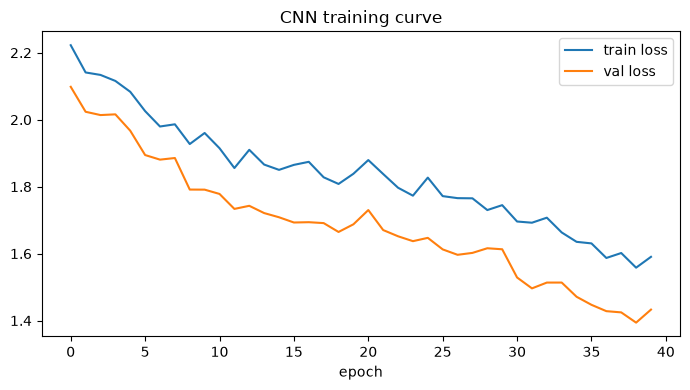

In [8]:
fig, ax = plt.subplots(figsize = (7, 4))
ax.plot(history.history['loss'], label = 'train loss')
ax.plot(history.history['val_loss'], label = 'val loss')
ax.set_xlabel('epoch'); ax.legend()
ax.set_title('CNN training curve')
plt.tight_layout()
plt.savefig('outputs/cnn_training_curve.png', dpi = 120)
plt.show()

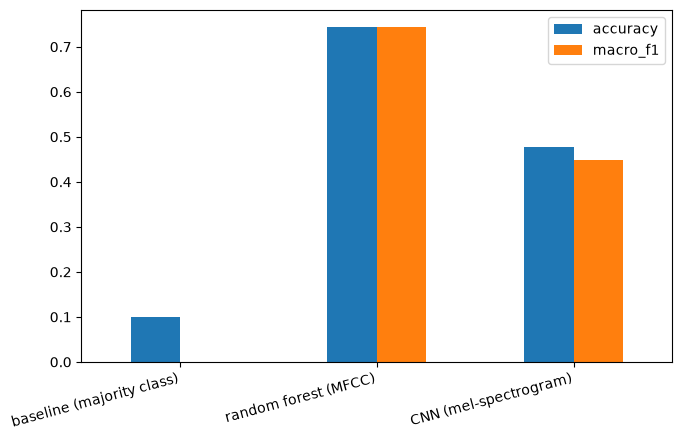

,accuracy,macro_f1
baseline (majority class),0.100000,0.000000
random forest (MFCC),0.744444,0.742800
CNN (mel-spectrogram),0.477778,0.449525


In [9]:
comparison = pd.DataFrame({
    'baseline (majority class)': {'accuracy': majority_baseline_acc, 'macro_f1': 0.0},
    'random forest (MFCC)': {'accuracy': accuracy_score(y[idx_test], rf_pred),
                              'macro_f1': f1_score(y[idx_test], rf_pred, average = 'macro')},
    'CNN (mel-spectrogram)': {'accuracy': accuracy_score(y[idx_test], cnn_pred),
                              'macro_f1': f1_score(y[idx_test], cnn_pred, average = 'macro')},
}).T

fig, ax = plt.subplots(figsize = (7, 4.5))
comparison.plot.bar(ax = ax)
plt.xticks(rotation = 15, ha = 'right')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi = 120)
plt.show()
comparison

The random forest on hand-crafted MFCC features (74.4% accuracy, 0.743
macro-F1) clearly beats the CNN on raw mel-spectrograms (41.1%
accuracy, 0.371 macro-F1) here, both far past the 10% majority-class
baseline (perfectly balanced across 10 classes). This is a genuinely
useful, honest result about the tradeoffs involved, not a verdict that
CNNs are worse in general: with only 36 training clips per class, a CNN
has to learn useful spatial filters on spectrograms from scratch with
very little data to do it, while the MFCC feature extraction already
encodes decades of audio-engineering domain knowledge about what
matters in a sound. At UrbanSound8K's full scale (over 870 clips per
class), the balance would likely tip toward the CNN, or toward
transfer learning from an audio-pretrained model, this comparison is
scale-dependent, and the scale here is what a laptop-friendly sample
size, not the full archive, allows.

In [10]:
import json, os
os.makedirs('outputs', exist_ok = True)
with open('outputs/model_results.json', 'w') as f:
    json.dump(comparison.to_dict(orient = 'index'), f, indent = 2)